In [1]:
import json, hashlib, os
import numpy as np
import bilby
from bilby.core.utils.random import seed as bilby_seed

# =========================
# User input (edit this)
# =========================
META_PATH = "outputs/outdir_population_meta/event_0006/meta.json"

# Optional: tolerances for SNR comparison (stored vs replay)
ATOL = 1e-6
RTOL = 1e-4


# =========================
# Helpers
# =========================
def _sha256(arr: np.ndarray) -> str:
    arr = np.ascontiguousarray(arr)
    return hashlib.sha256(arr.tobytes()).hexdigest()

def _load_meta(meta_path: str) -> dict:
    with open(meta_path, "r", encoding="utf-8") as f:
        return json.load(f)

def _get(meta: dict, *keys, default=None):
    """Try meta[k1][k2]... fallback to top-level."""
    cur = meta
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

def _build_ifos(ifo_files, fmin):
    ifos = bilby.gw.detector.InterferometerList(
        [bilby.gw.detector.load_interferometer(f) for f in ifo_files]
    )
    for ifo in ifos:
        ifo.minimum_frequency = float(fmin)
    return ifos

def _build_wg(duration, fs, waveform_arguments):
    return bilby.gw.WaveformGenerator(
        duration=int(duration),
        sampling_frequency=float(fs),
        frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star_relative_binning,
        parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters,
        waveform_arguments=waveform_arguments,
    )

def replay_once(meta: dict):
    inj = meta["injection_parameters"]
    noise_seed = int(meta["noise_seed"])

    duration = int(_get(meta, "data_segment", "duration", default=_get(meta, "duration", default=1024)))
    start_time = float(_get(meta, "data_segment", "start_time",
                            default=_get(meta, "start_time", default=float(inj["geocent_time"] + 2 - duration))))
    fs = float(_get(meta, "data_segment", "sampling_frequency", default=_get(meta, "sampling_frequency", default=8192)))
    fmin = float(_get(meta, "data_segment", "fmin", default=_get(meta, "fmin", default=10.0)))

    ifo_files = _get(meta, "reproduction", "ifo_files", default=_get(meta, "ifo_files", default=None))
    if ifo_files is None:
        raise ValueError("Cannot find ifo_files in meta['reproduction']['ifo_files'] or meta['ifo_files'].")

    waveform_arguments = _get(meta, "reproduction", "waveform_arguments",
                              default=_get(meta, "waveform_arguments", default={}))
    if not isinstance(waveform_arguments, dict):
        raise ValueError("waveform_arguments must be a dict in meta.")

    # fresh objects each call (for clean determinism check)
    ifos = _build_ifos(ifo_files, fmin)
    wg = _build_wg(duration, fs, waveform_arguments)

    # seed RIGHT BEFORE noise generation (deterministic noise realization)
    bilby_seed(noise_seed)
    ifos.set_strain_data_from_power_spectral_densities(
        sampling_frequency=fs,
        duration=duration,
        start_time=start_time,
    )

    # inject
    ifos.inject_signal(parameters=inj, waveform_generator=wg)

    # matched-filter SNR
    pols = wg.frequency_domain_strain(parameters=inj)
    ifo_snrs = {}
    hashes = {}
    for ifo in ifos:
        sig = ifo.get_detector_response(pols, inj)
        snr_cplx = bilby.gw.utils.matched_filter_snr(
            signal=sig,
            frequency_domain_strain=ifo.strain_data.frequency_domain_strain,
            power_spectral_density=ifo.power_spectral_density_array,  # documented attribute :contentReference[oaicite:3]{index=3}
            duration=duration,  # signature documented :contentReference[oaicite:4]{index=4}
        )
        ifo_snrs[ifo.name] = float(np.abs(snr_cplx))

        # hash the final data (noise + signal) in frequency domain
        hashes[ifo.name] = _sha256(np.asarray(ifo.strain_data.frequency_domain_strain))

    network_snr = float(np.sqrt(np.sum([s**2 for s in ifo_snrs.values()])))
    return {"ifo_snrs": ifo_snrs, "network_snr": network_snr}, hashes

def compare_snrs(stored: dict, replayed: dict, atol=ATOL, rtol=RTOL):
    msgs = []
    ok = True

    s_net = float(stored.get("network_snr", np.nan))
    r_net = float(replayed.get("network_snr", np.nan))
    diff = abs(r_net - s_net)
    tol = atol + rtol * abs(s_net)
    ok &= (diff <= tol)
    msgs.append(f"network_snr: stored={s_net:.6g} replay={r_net:.6g} |diff|={diff:.3g} tol={tol:.3g}")

    s_ifo = stored.get("ifo_snrs", {}) or {}
    r_ifo = replayed.get("ifo_snrs", {}) or {}
    for k in sorted(set(s_ifo.keys()) | set(r_ifo.keys())):
        sv = float(s_ifo.get(k, np.nan))
        rv = float(r_ifo.get(k, np.nan))
        diff = abs(rv - sv)
        tol = atol + rtol * abs(sv)
        ok &= (diff <= tol)
        msgs.append(f"{k}: stored={sv:.6g} replay={rv:.6g} |diff|={diff:.3g} tol={tol:.3g}")

    return ok, msgs

def check_meta(meta_path=META_PATH, atol=ATOL, rtol=RTOL, show_hash_prefix=12):
    meta = _load_meta(meta_path)

    stored = {
        "network_snr": meta.get("network_snr", np.nan),
        "ifo_snrs": meta.get("ifo_snrs", {}) or {},
    }

    # replay once: compare SNR to stored
    res1, h1 = replay_once(meta)
    ok_snr, snr_msgs = compare_snrs(stored, res1, atol=atol, rtol=rtol)

    # replay twice: determinism (bitwise) check in *this* environment
    res2, h2 = replay_once(meta)
    ok_hash = (h1 == h2)

    print(f"=== Replay check: {meta_path} ===")
    print(f"noise_seed={meta['noise_seed']}")
    seg = meta.get("data_segment", {})
    if seg:
        print(f"duration={seg.get('duration')}  start_time={seg.get('start_time')}  fs={seg.get('sampling_frequency')}  fmin={seg.get('fmin')}")
    print("\nSNR comparison (stored vs replay):")
    for m in snr_msgs:
        print("  " + m)

    print("\nDeterminism check (replay twice):")
    for ifo_name in sorted(h1.keys()):
        same = (h1[ifo_name] == h2.get(ifo_name, ""))
        p1 = h1[ifo_name][:show_hash_prefix]
        p2 = h2.get(ifo_name, "")[:show_hash_prefix]
        print(f"  {ifo_name}: {p1}... vs {p2}...  same={same}")

    print("\nRESULT:", "PASS ✅" if (ok_snr and ok_hash) else "FAIL ❌")
    if not ok_snr:
        print("  - SNR mismatch beyond tolerance")
    if not ok_hash:
        print("  - data hashes differ between the two replays (not bitwise deterministic in this env)")

    return {
        "ok_snr": ok_snr,
        "ok_hash": ok_hash,
        "stored": stored,
        "replay1": res1,
        "replay2": res2,
        "hash1": h1,
        "hash2": h2,
    }


# =========================
# Run
# =========================
summary = check_meta(META_PATH)
summary



11:00 bilby INFO    : Waveform generator instantiated: WaveformGenerator(duration=1024, sampling_frequency=8192.0, start_time=0, frequency_domain_source_model=bilby.gw.source.lal_binary_neutron_star_relative_binning, time_domain_source_model=None, parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_neutron_star_parameters, waveform_arguments={'fiducial': 1, 'minimum_frequency': 10.0, 'reference_frequency': 10.0, 'waveform_approximant': 'IMRPhenomXP_NRTidalv3'})
/home/fy6204/.conda/envs/GW/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jup

=== Replay check: outdir_population_meta/event_0006/meta.json ===
noise_seed=130
duration=1024  start_time=1126258620.413  fs=8192  fmin=10.0

SNR comparison (stored vs replay):
  network_snr: stored=63.6918 replay=63.6918 |diff|=0 tol=0.00637
  CE-A40: stored=62.5403 replay=62.5403 |diff|=0 tol=0.00626
  CE-B20: stored=12.0563 replay=12.0563 |diff|=0 tol=0.00121

Determinism check (replay twice):
  CE-A40: 78f0a2c57186... vs 78f0a2c57186...  same=True
  CE-B20: 071aa35bda6e... vs 071aa35bda6e...  same=True

RESULT: PASS ✅


{'ok_snr': True,
 'ok_hash': True,
 'stored': {'network_snr': 63.69183704478906,
  'ifo_snrs': {'CE-A40': 62.5403436219353, 'CE-B20': 12.056347945801043}},
 'replay1': {'ifo_snrs': {'CE-B20': 12.056347945801043,
   'CE-A40': 62.5403436219353},
  'network_snr': 63.69183704478906},
 'replay2': {'ifo_snrs': {'CE-B20': 12.056347945801043,
   'CE-A40': 62.5403436219353},
  'network_snr': 63.69183704478906},
 'hash1': {'CE-B20': '071aa35bda6efb554d1bda7edd59ff7dd5f46008fb83ea065367add556356962',
  'CE-A40': '78f0a2c57186d77fa800d5363eeebc19099eb21145b9b2df5fc8c06ec3830e5a'},
 'hash2': {'CE-B20': '071aa35bda6efb554d1bda7edd59ff7dd5f46008fb83ea065367add556356962',
  'CE-A40': '78f0a2c57186d77fa800d5363eeebc19099eb21145b9b2df5fc8c06ec3830e5a'}}

Loaded accepted events: 100
m_src: mean=1.337, std=0.092
dL:    min=189.8 Mpc, max=1591.0 Mpc, median=1092.9 Mpc
z:     min=0.0415, max=0.2981, median=0.2142


/tmp/ipykernel_1553260/3515929283.py:85: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm = np.trapz(p_dL_unnorm, dL_grid)


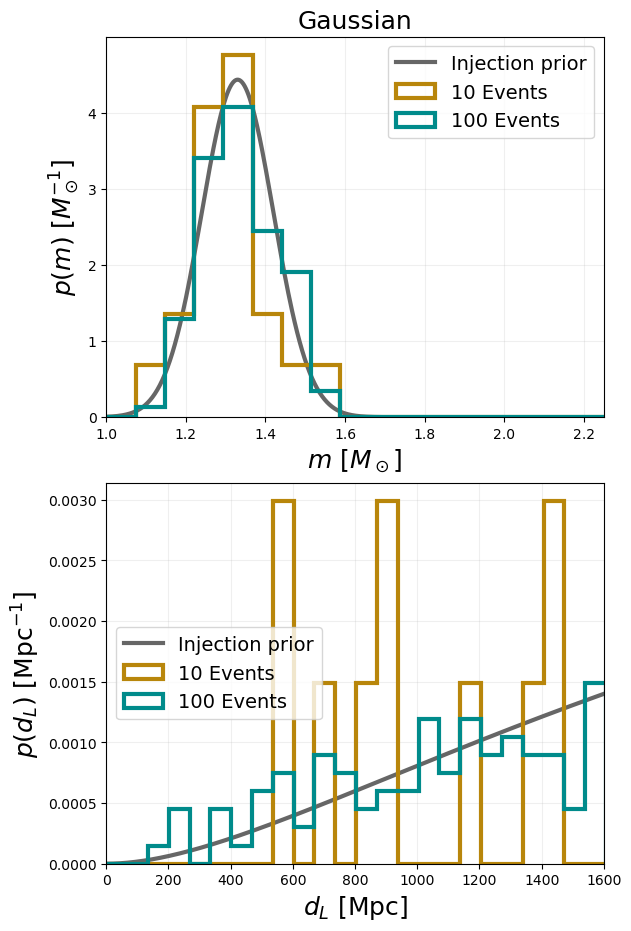

In [1]:
import glob, json, os, math
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18

# ======================
# USER SETTINGS
# ======================
OUTDIR = "outputs/outdir_population_meta"   # 你的输出目录
N_LIST = [10, 100]                    # 画几条直方图：比如 5 events / 50 events
RANDOM_SUBSET = False               # True: 随机抽样；False: 取前 N 个
RNG_SEED = 123

# injection prior (应与生成脚本一致)
M_MIN, M_MAX = 1.0, 2.25
M_MU, M_SIGMA = 1.33, 0.09
Z_MAX = 0.3
GAMMA = 0.0  # p(z) ∝ dVc/dz * (1+z)^{gamma-1}

# hist bins
M_BINS = np.linspace(1.0, 2.25, 18)


# ======================
# LOAD META
# ======================
meta_paths = sorted(glob.glob(os.path.join(OUTDIR, "event_*", "meta.json")))
if len(meta_paths) == 0:
    raise FileNotFoundError(f"No meta.json found under {OUTDIR}/event_*/meta.json")

metas = []
for p in meta_paths:
    with open(p, "r", encoding="utf-8") as f:
        metas.append(json.load(f))

# arrays (accepted events)
m1s = np.array([m["mass_1_source"] for m in metas], dtype=float)
m2s = np.array([m["mass_2_source"] for m in metas], dtype=float)
m_src_all = np.concatenate([m1s, m2s])  # component-mass sample (source frame)

dL = np.array([m.get("luminosity_distance_mpc", m["injection_parameters"]["luminosity_distance"]) for m in metas], dtype=float)
# 覆盖全部 accepted 事件的距离范围
DL_MAX = float(dL.max())
DL_BINS = np.linspace(0.0, DL_MAX * 1.01, 25)  # 25 个bin你也可以改成 30/40

# optional: also look at z
z_arr = np.array([m["z"] for m in metas], dtype=float)

print(f"Loaded accepted events: {len(metas)}")
print(f"m_src: mean={m_src_all.mean():.3f}, std={m_src_all.std(ddof=1):.3f}")
print(f"dL:    min={dL.min():.1f} Mpc, max={dL.max():.1f} Mpc, median={np.median(dL):.1f} Mpc")
print(f"z:     min={z_arr.min():.4f}, max={z_arr.max():.4f}, median={np.median(z_arr):.4f}")

# ======================
# PRIOR CURVES
# ======================
def norm_pdf(x, mu, sig):
    return np.exp(-0.5*((x-mu)/sig)**2) / (sig*np.sqrt(2*np.pi))

def norm_cdf(x, mu, sig):
    # Gaussian CDF via erf (no scipy needed)
    t = (x - mu) / (sig*np.sqrt(2))
    return 0.5*(1 + np.vectorize(math.erf)(t))

def trunc_gaussian_pdf(x, mu, sig, a, b):
    Z = norm_cdf(b, mu, sig) - norm_cdf(a, mu, sig)
    p = norm_pdf(x, mu, sig) / Z
    p[(x < a) | (x > b)] = 0.0
    return p

# mass prior curve
m_grid = np.linspace(M_MIN, M_MAX, 400)
p_m = trunc_gaussian_pdf(m_grid, M_MU, M_SIGMA, M_MIN, M_MAX)

# distance prior curve from p(z) ∝ dVc/dz * (1+z)^{gamma-1}, z in [0, Z_MAX]
z_grid = np.linspace(0, Z_MAX, 4000)
dVc_dz = (4*np.pi) * Planck18.differential_comoving_volume(z_grid).value  # Mpc^3 per dz
p_z_unnorm = dVc_dz * (1 + z_grid)**(GAMMA - 1.0)

dL_grid = Planck18.luminosity_distance(z_grid).value  # Mpc
ddL_dz = np.gradient(dL_grid, z_grid)
p_dL_unnorm = p_z_unnorm / np.abs(ddL_dz)

# normalize p(dL) over [0, dL(Z_MAX)]
norm = np.trapz(p_dL_unnorm, dL_grid)
p_dL = p_dL_unnorm / norm

# ======================
# PLOTTING
# ======================
rng = np.random.default_rng(RNG_SEED)

fig, axs = plt.subplots(2, 1, figsize=(6.2, 9.2), constrained_layout=True)

# --- top: p(m) ---
ax = axs[0]
ax.plot(m_grid, p_m, lw=3, color="0.4", label="Injection prior")

colors = ["#b8860b", "#008b8b", "#6a5acd", "#d2691e"]  # simple distinguishable colors
for i, N in enumerate(N_LIST):
    if N > len(metas):
        print(f"Skip N={N} (only {len(metas)} events available)")
        continue
    if RANDOM_SUBSET:
        idx = rng.choice(len(metas), size=N, replace=False)
    else:
        idx = np.arange(N)

    ms = np.concatenate([m1s[idx], m2s[idx]])
    ax.hist(ms, bins=M_BINS, density=True, histtype="step", lw=3, color=colors[i % len(colors)], label=f"{N} Events")

ax.set_title("Gaussian", fontsize=18)
ax.set_xlabel(r"$m\ [M_\odot]$", fontsize=18)
ax.set_ylabel(r"$p(m)\ [M_\odot^{-1}]$", fontsize=18)
ax.set_xlim(1.0, 2.25)
ax.legend(frameon=True, fontsize=14)
ax.grid(alpha=0.2)

# --- bottom: p(dL) ---
ax = axs[1]
ax.plot(dL_grid, p_dL, lw=3, color="0.4", label="Injection prior")

for i, N in enumerate(N_LIST):
    if N > len(metas):
        continue
    if RANDOM_SUBSET:
        idx = rng.choice(len(metas), size=N, replace=False)
    else:
        idx = np.arange(N)

    ax.hist(dL[idx], bins=DL_BINS, density=True, histtype="step", lw=3, color=colors[i % len(colors)], label=f"{N} Events")

ax.set_xlabel(r"$d_L\ [\mathrm{Mpc}]$", fontsize=18)
ax.set_ylabel(r"$p(d_L)\ [\mathrm{Mpc}^{-1}]$", fontsize=18)
ax.set_xlim(0, 1600)
ax.legend(frameon=True, fontsize=14)
ax.grid(alpha=0.2)

plt.show()


In [8]:
print(max(m1s), max(m2s))
print(min(m1s), min(m2s))

1.5360918952583122 1.4849290901177896
1.2226528071120353 1.1345160501983338
